# DataLab-Kernel — Advanced Plotting Showcase

[DataLab](https://datalab-platform.com) is an open-source platform for scientific and technical data processing — this notebook demonstrates the **interactive visualization** features of its **Jupyter kernel extension**, DataLab-Kernel.

Unlike the Quick Start notebook (which connects to a running DataLab instance),
this notebook works entirely in **standalone mode** — no DataLab GUI needed.
We create signals and images programmatically with [Sigima](https://sigima.readthedocs.io/)
and render them with the Plotly backend.

## Demonstrated features

- **Interactive Plotly backend** — zoom, pan, hover over every plot
- **Unified `plotter.plot()` API** — pass a single object or a list of signals/images
- **ROI visualization** — shaded regions on signals, rectangles/circles on images
- **Geometry & table result overlays** — FWHM segments, detected blobs, statistics
- **Curve styles** — Lines, Steps, Sticks, custom colors and dash patterns
- **Colormaps & LUT range** — control color mapping and contrast
- **Log scale, error bars, non-uniform coordinates**

## 1. Setup

### Import the extension

If you haven't already, run the following cell to load the `datalab_kernel` extension and import necessary libraries. You can skip re-importing libraries in subsequent cells. This will start the kernel in standalone mode, allowing you to run the notebook without a DataLab instance (it may take a few seconds to initialize because it first tries to connect to DataLab, then falls back to standalone mode when it fails).

In [1]:
%load_ext datalab_kernel

INFO:datalab-kernel:DataLab Kernel 0.2.10 started in standalone mode
INFO:datalab-kernel:DataLab extension loaded successfully


In [2]:
import numpy as np
import sigima.objects
import sigima.proc.image
import sigima.proc.signal

### Set the plotting backend (optional)

Choose one of the following lines to set either the Plotly or Matplotlib backend. The rest of the code is the same regardless of the backend. You may also skip this step and use the default Plotly backend.

> Note: the comments with `# type: ignore` and `# noqa: F821` hide unsightly warnings in the notebook editor, since the `plotter` variable is injected by the `datalab_kernel` extension, but they are absolutely *not necessary* for the code to run.

In [4]:
plotter.set_backend("matplotlib")  # type: ignore # noqa: F821

In [3]:
plotter.set_backend("plotly")  # type: ignore # noqa: F821

---
## 2. Rich Signal — All features combined

A single plot showcasing **error bars**, **ROI regions**, **axis bounds**,
**geometry overlays** (FWHM segment), and **statistics table** — all rendered
interactively. The signal contains two Gaussian peaks and FWHM is computed
on each ROI.

In [3]:
# Build a rich signal with every feature — two Gaussian peaks
np.random.seed(42)
n = 500
x = np.linspace(0, 10, n)

# Two Gaussian bumps centered at x=3 and x=7
y = (
    0.8 * np.exp(-((x - 3.0) ** 2) / (2 * 0.4**2))
    + 1.0 * np.exp(-((x - 7.0) ** 2) / (2 * 0.6**2))
    + 0.02 * np.random.randn(n)
)
dx = np.full(n, 0.01)
dy = np.abs(y) * 0.05 + 0.005

sig_rich = sigima.objects.create_signal(
    title="Double peak", x=x, y=y, dx=dx, dy=dy,
    labels=("Position", "Intensity"), units=("mm", "a.u."),
)
sig_rich.roi = sigima.objects.create_signal_roi([[1.5, 4.5], [5.5, 8.5]])
sig_rich.autoscale = False
sig_rich.xscalemin, sig_rich.xscalemax = 0.0, 10.0
sig_rich.yscalemin, sig_rich.yscalemax = -0.2, 1.3
sig_rich.set_metadata_option("shade", 0.2)

# Compute analysis results with Sigima and embed in metadata for overlay
fwhm_result = sigima.proc.signal.fwhm(sig_rich)
if fwhm_result is not None:
    sig_rich.metadata["Geometry_fwhm"] = fwhm_result.to_dict()

stats_result = sigima.proc.signal.stats(sig_rich)
sig_rich.metadata["Table_statistics"] = stats_result.to_dict()

plotter.plot(sig_rich, title="Rich Signal — All Features", show_roi=True)

c:\Dev\DataLab-Kernel\.venv\Lib\site-packages\sigima\tools\signal\pulse.py:1347: UserWarning: Multiple crossing points found. Returning first.
  warnings.warn("Multiple crossing points found. Returning first.")
c:\Dev\DataLab-Kernel\.venv\Lib\site-packages\sigima\tools\signal\pulse.py:1358: UserWarning: Multiple crossing points found. Returning last.
  warnings.warn("Multiple crossing points found. Returning last.")


---
## 3. Curve Styles — Lines, Steps, Sticks

DataLab-Kernel supports different curve rendering styles via metadata.
Compare them side by side:

In [4]:
x_steps = np.linspace(0, 5, 30)
y_steps = np.floor(np.sin(2 * np.pi * 0.5 * x_steps) * 3)
sig_steps = sigima.objects.create_signal(title="Steps", x=x_steps, y=y_steps)
sig_steps.set_metadata_option("curvestyle", "Steps")

x_sticks = np.linspace(0, 10, 50)
y_sticks = np.sin(2 * np.pi * 0.3 * x_sticks)
sig_sticks = sigima.objects.create_signal(title="Sticks", x=x_sticks, y=y_sticks)
sig_sticks.set_metadata_option("curvestyle", "Sticks")

x_lines = np.linspace(0, 10, 200)
y_lines = np.cos(2 * np.pi * 0.5 * x_lines)
sig_lines = sigima.objects.create_signal(title="Lines (custom style)", x=x_lines, y=y_lines)
sig_lines.metadata["color"] = "red"
sig_lines.metadata["linestyle"] = "DashLine"
sig_lines.metadata["linewidth"] = 2

plotter.plot(
    [sig_lines, sig_steps, sig_sticks],
    title="Curve Styles Comparison",
)

---
## 4. Log Scale — Bandpass filter response

Log-log plots are essential for frequency analysis. This example shows a
second-order Butterworth bandpass filter response where the passband and
roll-off are immediately visible on a logarithmic scale.

In [5]:
# Second-order Butterworth bandpass filter response
from scipy.signal import butter, freqz

b, a = butter(2, [0.05, 0.3], btype="band")
w, h = freqz(b, a, worN=2000)
freq = w / np.pi * 500  # Convert to Hz (assuming 1 kHz sample rate)
mag = np.abs(h)
# Avoid log(0) by clipping
mag = np.clip(mag, 1e-6, None)

sig_log = sigima.objects.create_signal(
    title="Bandpass filter", x=freq[1:], y=mag[1:],
    labels=("Frequency", "Magnitude"), units=("Hz", ""),
)
sig_log.xscalelog = True
sig_log.yscalelog = True

plotter.plot(sig_log, title="Bandpass Filter Response (Log-Log)")

---
## 5. Error Bars

Display measurement uncertainty with dx/dy error bars on a decaying
oscillation.

In [6]:
x_eb = np.linspace(0, 10, 200)
y_eb = np.exp(-0.3 * x_eb) * np.sin(2 * np.pi * 0.5 * x_eb)
dx_eb = np.full_like(x_eb, 0.05)
dy_eb = np.abs(y_eb) * 0.15 + 0.02

sig_eb = sigima.objects.create_signal(
    title="Decaying oscillation", x=x_eb, y=y_eb, dx=dx_eb, dy=dy_eb,
    labels=("Frequency", "Power"), units=("Hz", "dB"),
)

plotter.plot(sig_eb, title="Signal with Error Bars")

---
## 6. Multi-Signal Overlay

Compare multiple signals on a single interactive plot. Supports
SignalObj, plain numpy arrays, and (x, y) tuples.

In [7]:
# Three sine waves at different frequencies
sigs = [
    sigima.objects.create_signal(
        title=f"f = {f} Hz",
        x=np.linspace(0, 10, 500),
        y=np.sin(2 * np.pi * f * np.linspace(0, 10, 500)),
        labels=("Time", "Amplitude"), units=("s", "V"),
    )
    for f in [0.5, 1.0, 1.5]
]
# Add two named ROIs on the first signal
roi = sigima.objects.create_signal_roi([[1.0, 3.5], [6.0, 8.5]])
for idx, title in enumerate(["Low-freq half-period", "Interference zone"]):
    roi[idx].title = title
sigs[0].roi = roi

plotter.plot(sigs, title="Multi-Signal Overlay with ROI", show_roi=True)

---
## 7. Rich Image — ROIs, Colormap, LUT range, and Analysis

A 2D image with custom coordinates, colormap, contrast control (LUT range),
ROI overlays, and analysis results (centroid, statistics) computed by Sigima.

In [8]:
shape = (200, 300)
yc = np.linspace(-2, 2, shape[0])[:, np.newaxis]
xc = np.linspace(-2, 2, shape[1])[np.newaxis, :]
data = (np.sin(xc * 3) * np.cos(yc * 2) + 1).astype(np.float32) / 2

img_rich = sigima.objects.create_image(
    title="Interference pattern", data=data,
    labels=("X", "Y", "Intensity"), units=("µm", "µm", "counts"),
)
img_rich.set_uniform_coords(dx=0.5, dy=0.5, x0=10.0, y0=20.0)

# ROIs: rectangle and circle
roi = sigima.objects.ImageROI()
roi.add_roi(sigima.objects.RectangularROI([30.0, 40.0, 80.0, 60.0], indices=False, title="Region A"))
roi.add_roi(sigima.objects.CircularROI([100.0, 80.0, 25.0], indices=False, title="Spot"))
img_rich.roi = roi

# LUT range and colormap
img_rich.autoscale = False
img_rich.zscalemin = 0.1
img_rich.zscalemax = 0.9
img_rich.set_metadata_option("colormap", "viridis")

# Compute analysis results with Sigima and embed in metadata for overlay
centroid_result = sigima.proc.image.centroid(img_rich)
if centroid_result is not None:
    img_rich.metadata["Geometry_centroid"] = centroid_result.to_dict()

stats_result = sigima.proc.image.stats(img_rich)
img_rich.metadata["Table_statistics"] = stats_result.to_dict()

plotter.plot(img_rich, title="Rich Image — All Features", show_roi=True)

---
## 8. Colormaps — Side by side comparison

Compare the same pattern rendered with different colormaps in a multi-image grid.


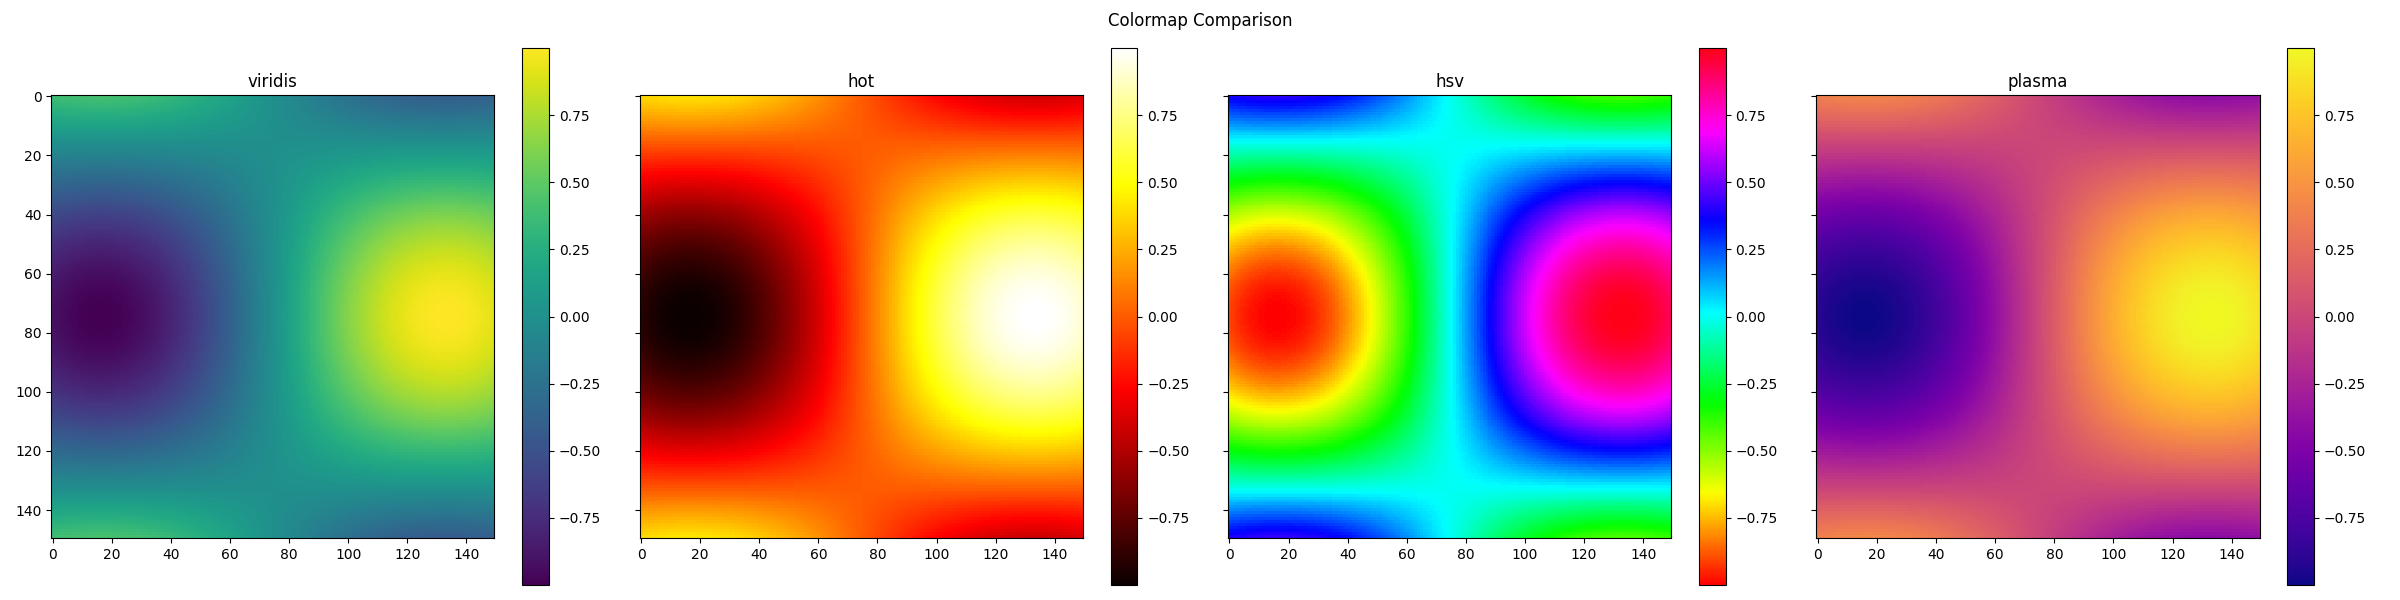

In [12]:
def make_colormap_image(cmap: str):
    """Create a 2D pattern with a given colormap."""
    shape = (150, 150)
    yc = np.linspace(-2, 2, shape[0])[:, np.newaxis]
    xc = np.linspace(-2, 2, shape[1])[np.newaxis, :]
    data = np.sin(xc) * np.cos(yc)
    img = sigima.objects.create_image(title=cmap, data=data.astype(np.float32))
    img.set_metadata_option("colormap", cmap)
    return img

colormaps = ["viridis", "hot", "hsv", "plasma"]
imgs_cmap = [make_colormap_image(c) for c in colormaps]

plotter.plot(imgs_cmap, title="Colormap Comparison", titles=colormaps)

---
## 9. Non-Uniform Image Coordinates

Images can have non-uniform coordinate spacing — useful for logarithmic
wavelength scales, adaptive sampling, or curved coordinate systems.
Here the **same sine-wave pattern** is shown with uniform vs non-uniform
coordinates: the warping of the pattern makes the coordinate distortion
immediately visible.

In [14]:
# Same sine-wave pattern rendered with two different coordinate systems
size = 100
row = np.arange(size)[:, np.newaxis]
col = np.arange(size)[np.newaxis, :]
data_pattern = (np.sin(col * 2 * np.pi / 20) * np.cos(row * 2 * np.pi / 20)).astype(
    np.float32
)

# Uniform coordinates — regular pixel spacing
img_uniform = sigima.objects.create_image(
    title="Uniform", data=data_pattern.copy(),
    labels=("X", "Y", "Intensity"), units=("µm", "µm", ""),
)
img_uniform.set_uniform_coords(dx=0.1, dy=0.1, x0=0.0, y0=0.0)

# Non-uniform coordinates — tanh(X) denser near center, quadratic(Y) denser at top
x_nu = 5.0 + 5.0 * np.tanh(np.linspace(-2.5, 2.5, size))  # [~0, ~10] µm
y_nu = 10.0 * (np.linspace(0, 1, size) ** 2)                # [0, 10] µm

img_nonuniform = sigima.objects.create_image(
    title="Non-uniform", data=data_pattern.copy(),
    labels=("X", "Y", "Intensity"), units=("µm", "µm", ""),
)
img_nonuniform.set_coords(xcoords=x_nu, ycoords=y_nu)

plotter.plot(
    [img_uniform, img_nonuniform],
    title="Uniform vs Non-Uniform Coordinates",
    titles=["Uniform (regular spacing)", "Non-uniform (tanh × quadratic)"],
)

---
## 10. Image with Geometry Overlays

Overlay multiple geometry results (enclosing circle and centroid computed by
Sigima) on a Gaussian spot image.

In [10]:
# Gaussian spot image
shape_g = (128, 128)
yg = np.linspace(-1, 1, shape_g[0])[:, np.newaxis]
xg = np.linspace(-1, 1, shape_g[1])[np.newaxis, :]
data_g = np.exp(-(xg**2 + yg**2)).astype(np.float32)
img_gauss = sigima.objects.create_image(title="Gaussian spot", data=data_g)

# Compute geometry results with Sigima
circle_result = sigima.proc.image.enclosing_circle(img_gauss)
centroid_result = sigima.proc.image.centroid(img_gauss)

plotter.plot(
    img_gauss, title="Image with Geometry Overlays",
    results=[circle_result, centroid_result],
)

,Value
x,63
y,63
r,47.5
,Value
x,63.5
y,63.5


---
## 11. Sigima Processing Pipeline

Combine Sigima processing with Plotly visualization. Process a signal through
a filter pipeline and compare before/after.

In [11]:
# Create a noisy signal
np.random.seed(0)
x_proc = np.linspace(0, 10, 1000)
y_proc = np.sin(2 * np.pi * x_proc) + 0.5 * np.random.randn(1000)
sig_noisy = sigima.objects.create_signal(
    title="Noisy signal", x=x_proc, y=y_proc,
    labels=("Time", "Amplitude"), units=("s", "V"),
)

# Apply moving average filter, then normalize
sig_filtered = sigima.proc.signal.moving_average(sig_noisy, n=30)
sig_norm = sigima.proc.signal.normalize(sig_filtered)

plotter.plot(
    [sig_noisy, sig_filtered, sig_norm],
    title="Processing Pipeline: Raw → Filtered → Normalized",
)

---
## 12. Analysis Results Display

Table and geometry results render as rich HTML tables — useful for
reporting statistics per ROI, FWHM measurements, or detection results.

In [12]:
# Compute statistics on the double-peak signal from section 2 (with 2 ROIs)
stats_result = sigima.proc.signal.stats(sig_rich)
plotter.display_table(stats_result, title="Signal statistics per ROI")

,min,max,mean,median,std,snr,ptp,sum,trapz
,-0.0518,1.03,0.23,0.0481,0.315,0.731,1.08,115,2.31
ROI 0,-0.0382,0.808,0.268,0.137,0.283,0.946,0.846,40.2,0.805
ROI 1,0.0227,1.03,0.496,0.478,0.33,1.5,1.01,74.5,1.49


In [13]:
# Compute centroid on the rich image from section 7 (with 2 ROIs)
centroid_result = sigima.proc.image.centroid(img_rich)
plotter.display_geometry(centroid_result, title="Image centroid per ROI")

,x,y
ROI 0,70.9,69.8
ROI 1,101,74.3


---

**Tip:** All Plotly plots are fully interactive — hover for values, zoom with
the scroll wheel, click-drag to select a region, and double-click to reset
the view.